In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:

dataset = pd.read_csv("../data/processed/clauses_clean.csv")

In [6]:
print("Shape:", dataset.shape)
dataset.head()

Shape: (22497, 9)


,point_id,quote_text,case_id,classification,label,topic_id,topic_title,service_id,document_id
0,6132,Both you and Stack Overflow hereby irrevocably...,242,bad,Risky,44,Jurisdiction and governing laws,312,352.0
1,9860,Sie haben jederzeit das Recht unentgeltlich Au...,195,good,Safe,34,User Choice,1700,1625.0
2,9859,"Ein Teil der Daten wird erhoben, um eine fehle...",196,good,Safe,41,Personal Data,1700,1625.0
3,4957,Please note that we are not responsible for ot...,278,neutral,Neutral,32,Guarantee,820,725.0
4,4960,"Your name, email address and optional informat...",228,good,Safe,36,Transparency,820,725.0


In [7]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 22497 entries, 0 to 22496
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   point_id        22497 non-null  int64  
 1   quote_text      22497 non-null  str    
 2   case_id         22497 non-null  int64  
 3   classification  22497 non-null  str    
 4   label           22497 non-null  str    
 5   topic_id        22497 non-null  int64  
 6   topic_title     22497 non-null  str    
 7   service_id      22497 non-null  int64  
 8   document_id     22486 non-null  float64
dtypes: float64(1), int64(4), str(4)
memory usage: 6.8 MB


In [8]:
dataset.describe(include="all")

,point_id,quote_text,case_id,classification,label,topic_id,topic_title,service_id,document_id
count,22497.000000,22497,22497.000000,22497,22497,22497.000000,22497,22497.000000,22486.000000
unique,NaN,22153,NaN,4,3,NaN,27,NaN,NaN
top,NaN,IP address,NaN,neutral,Neutral,NaN,Trackers,NaN,NaN
freq,NaN,12,NaN,9759,9759,NaN,2524,NaN,NaN
mean,20061.746677,NaN,258.129884,NaN,NaN,38.911766,NaN,2606.979508,4506.943209
std,8132.200619,NaN,93.214540,NaN,NaN,9.499232,NaN,2003.718061,3960.424251
min,560.000000,NaN,117.000000,NaN,NaN,25.000000,NaN,156.000000,2.000000
25%,13648.000000,NaN,183.000000,NaN,NaN,31.000000,NaN,831.000000,1457.000000
50%,20120.000000,NaN,242.000000,NaN,NaN,38.000000,NaN,2426.000000,3440.500000
75%,26913.000000,NaN,325.000000,NaN,NaN,47.000000,NaN,3553.000000,6516.000000


In [9]:
label_counts = dataset["label"].value_counts()

print(label_counts)

label
Neutral    9759
Risky      7015
Safe       5723
Name: count, dtype: int64


In [10]:
label_percent = dataset["label"].value_counts(normalize=True) * 100

print(label_percent.round(2))

label
Neutral    43.38
Risky      31.18
Safe       25.44
Name: proportion, dtype: float64


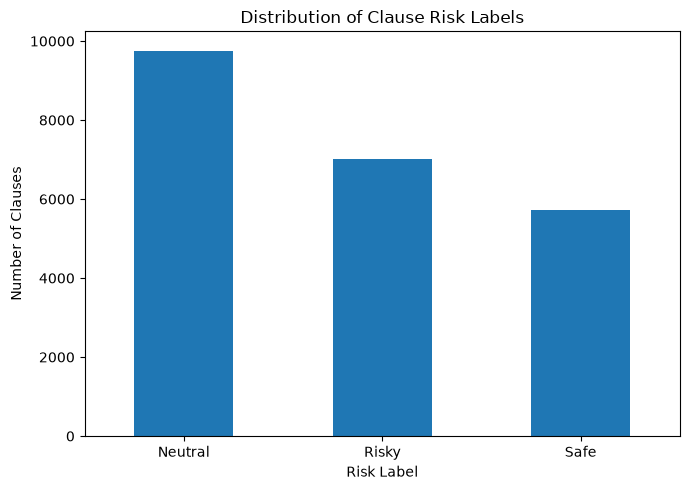

In [11]:
plt.figure(figsize=(7, 5))

dataset["label"].value_counts().plot(kind="bar")

plt.title("Distribution of Clause Risk Labels")
plt.xlabel("Risk Label")
plt.ylabel("Number of Clauses")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
print("Number of topics:", dataset["topic_title"].nunique())

Number of topics: 27


In [13]:
topic_counts = dataset["topic_title"].value_counts()

print(topic_counts)

topic_title
Trackers                              2524
Governance                            2476
Guarantee                             1603
Personal Data                         1575
Transparency                          1381
Content                               1231
Third Parties                         1154
Suspension and Censorship             1149
Notice of Changing Terms               979
Changes                                910
User Choice                            886
Jurisdiction and governing laws        883
Right to Leave The Service             759
Security                               728
Advertising                            663
Types of Information Collected         620
Copyright License                      557
Ownership                              411
Dispute Resolution                     377
Anonymity                              352
Law and Government Requests            348
Payments                               303
Business Transfers                     300

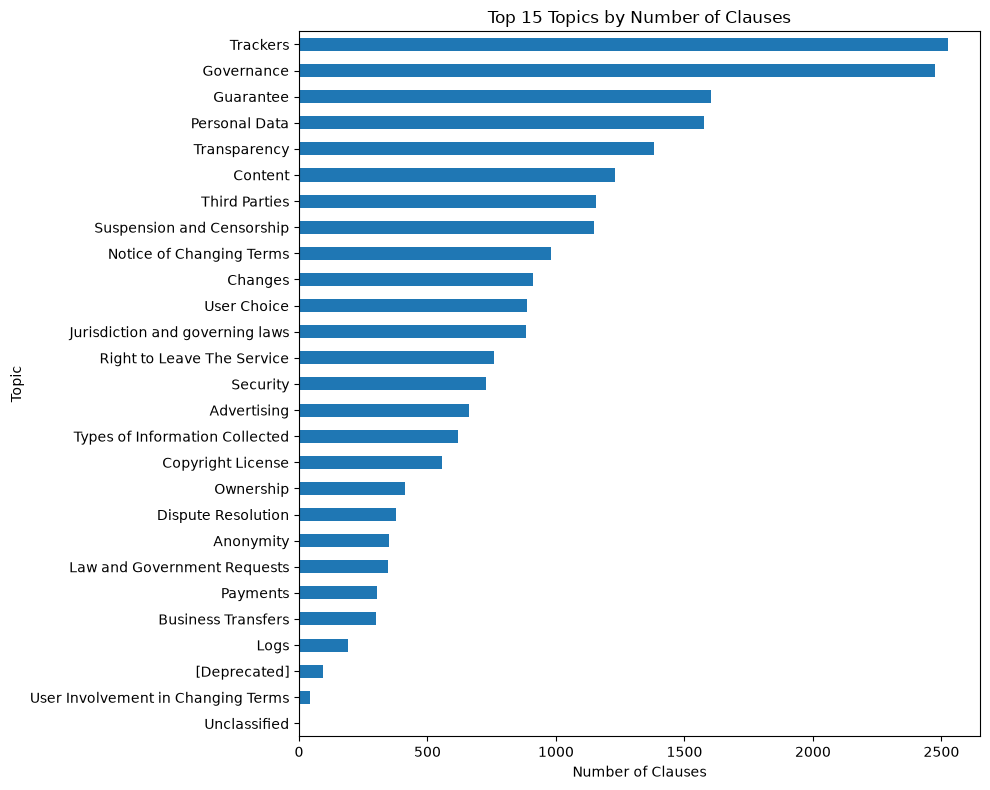

In [15]:
plt.figure(figsize=(10, 8))

topic_counts.sort_values().plot(kind="barh")

plt.title("Top 15 Topics by Number of Clauses")
plt.xlabel("Number of Clauses")
plt.ylabel("Topic")

plt.tight_layout()
plt.show()

In [16]:
topic_label_counts = pd.crosstab(
    dataset["topic_title"],
    dataset["label"]
)

print(topic_label_counts)

label                               Neutral  Risky  Safe
topic_title                                             
Advertising                               0    565    98
Anonymity                                68    202    82
Business Transfers                        0    265    35
Changes                                 909      1     0
Content                                1064     77    90
Copyright License                       216    134   207
Dispute Resolution                        0    338    39
Governance                             2209    241    26
Guarantee                              1447    127    29
Jurisdiction and governing laws         368    120   395
Law and Government Requests              54    144   150
Logs                                      0     53   138
Notice of Changing Terms                320    537   122
Ownership                                40    125   246
Payments                                223     20    60
Personal Data                  

In [17]:
topic_label_percent = pd.crosstab(
    dataset["topic_title"],
    dataset["label"],
    normalize="index"
) * 100

print(topic_label_percent.round(2))

label                               Neutral  Risky   Safe
topic_title                                              
Advertising                            0.00  85.22  14.78
Anonymity                             19.32  57.39  23.30
Business Transfers                     0.00  88.33  11.67
Changes                               99.89   0.11   0.00
Content                               86.43   6.26   7.31
Copyright License                     38.78  24.06  37.16
Dispute Resolution                     0.00  89.66  10.34
Governance                            89.22   9.73   1.05
Guarantee                             90.27   7.92   1.81
Jurisdiction and governing laws       41.68  13.59  44.73
Law and Government Requests           15.52  41.38  43.10
Logs                                   0.00  27.75  72.25
Notice of Changing Terms              32.69  54.85  12.46
Ownership                              9.73  30.41  59.85
Payments                              73.60   6.60  19.80
Personal Data 

In [18]:
dataset["text_length"] = dataset["quote_text"].str.len()

In [19]:
dataset["text_length"].describe()

count    22497.000000
mean       218.123572
std        251.628887
min          1.000000
25%         92.000000
50%        161.000000
75%        271.000000
max      13394.000000
Name: text_length, dtype: float64

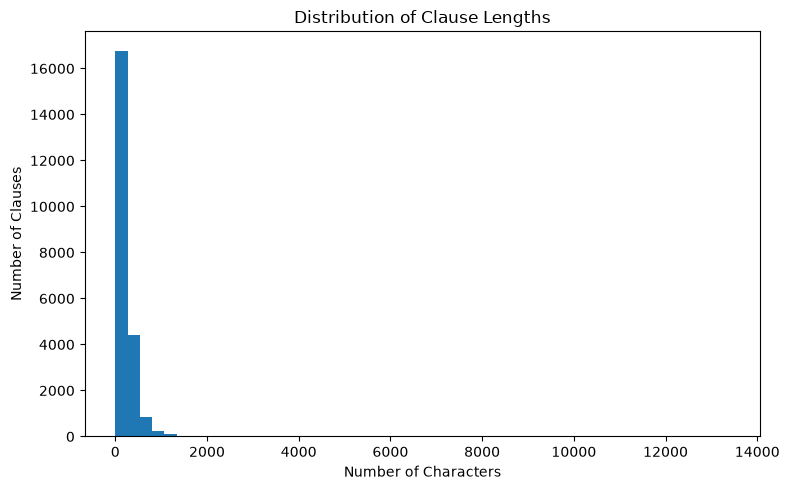

In [20]:
plt.figure(figsize=(8, 5))

plt.hist(dataset["text_length"], bins=50)

plt.title("Distribution of Clause Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Clauses")

plt.tight_layout()
plt.show()

In [21]:
dataset.groupby("label")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
Neutral,9759.0,202.827749,194.095245,1.0,82.0,149.0,258.0,3080.0
Risky,7015.0,243.789879,222.610179,2.0,118.0,191.0,301.0,4419.0
Safe,5723.0,212.745763,350.292696,4.0,79.0,146.0,250.0,13394.0


<Figure size 800x500 with 0 Axes>

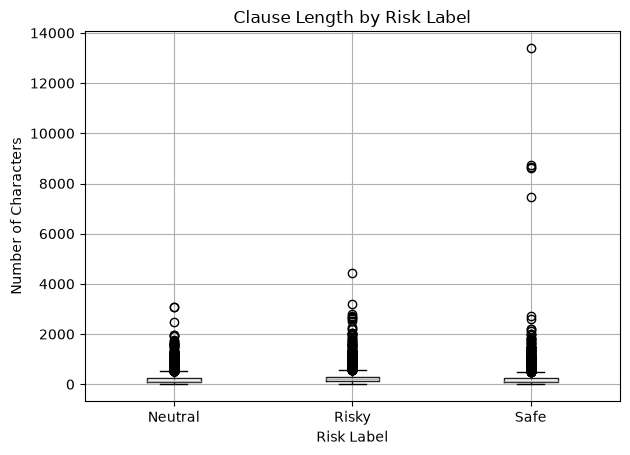

In [22]:
plt.figure(figsize=(8, 5))

dataset.boxplot(
    column="text_length",
    by="label"
)

plt.title("Clause Length by Risk Label")
plt.suptitle("")
plt.xlabel("Risk Label")
plt.ylabel("Number of Characters")

plt.tight_layout()
plt.show()

In [23]:
dataset["word_count"] = dataset["quote_text"].str.split().str.len()

In [24]:
dataset["word_count"].describe()

count    22497.000000
mean        34.047695
std         36.996835
min          1.000000
25%         15.000000
50%         26.000000
75%         43.000000
max       1652.000000
Name: word_count, dtype: float64

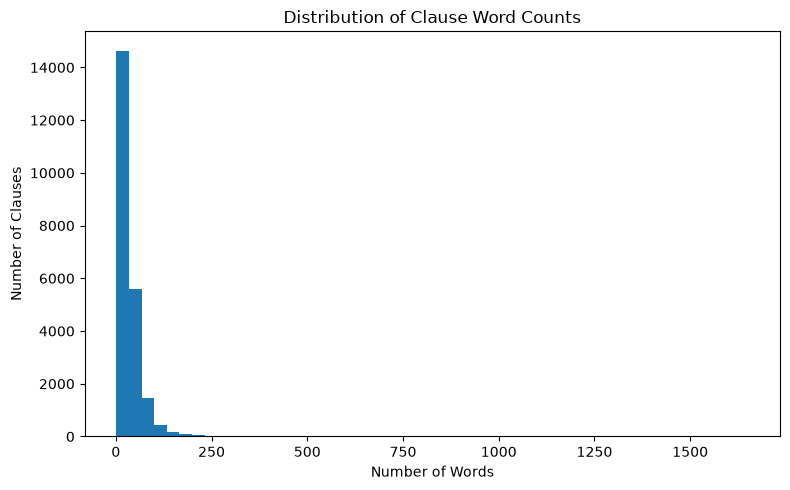

In [25]:
plt.figure(figsize=(8, 5))

plt.hist(dataset["word_count"], bins=50)

plt.title("Distribution of Clause Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Number of Clauses")

plt.tight_layout()
plt.show()


In [26]:
dataset.groupby("label")["word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
Neutral,9759.0,31.915155,29.912350,1.0,13.0,24.0,41.0,485.0
Risky,7015.0,37.748396,32.997042,1.0,19.0,30.0,47.0,628.0
Safe,5723.0,33.147999,49.954253,1.0,13.0,23.0,40.0,1652.0


<Figure size 800x500 with 0 Axes>

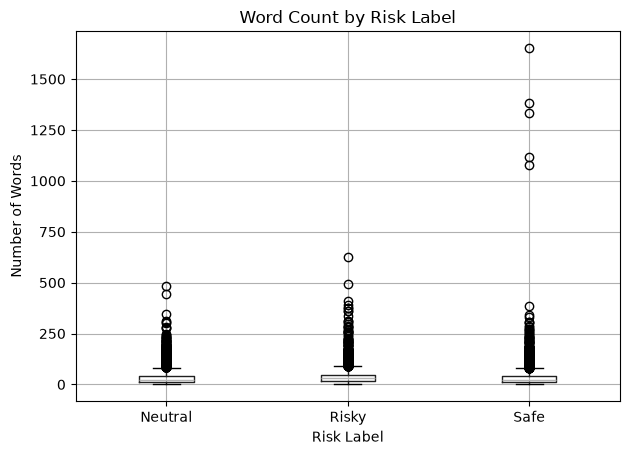

In [27]:
plt.figure(figsize=(8, 5))

dataset.boxplot(
    column="word_count",
    by="label"
)

plt.title("Word Count by Risk Label")
plt.suptitle("")
plt.xlabel("Risk Label")
plt.ylabel("Number of Words")

plt.tight_layout()
plt.show()

In [28]:
service_counts = dataset["service_id"].value_counts()

print("Number of services:", dataset["service_id"].nunique())
print(service_counts.head(20))

Number of services: 1781
service_id
2428    89
2453    80
1815    79
219     77
1553    76
217     71
1364    71
2461    69
846     69
2454    68
297     68
536     68
4521    67
200     66
194     66
2120    65
2475    65
3262    64
2572    63
225     62
Name: count, dtype: int64


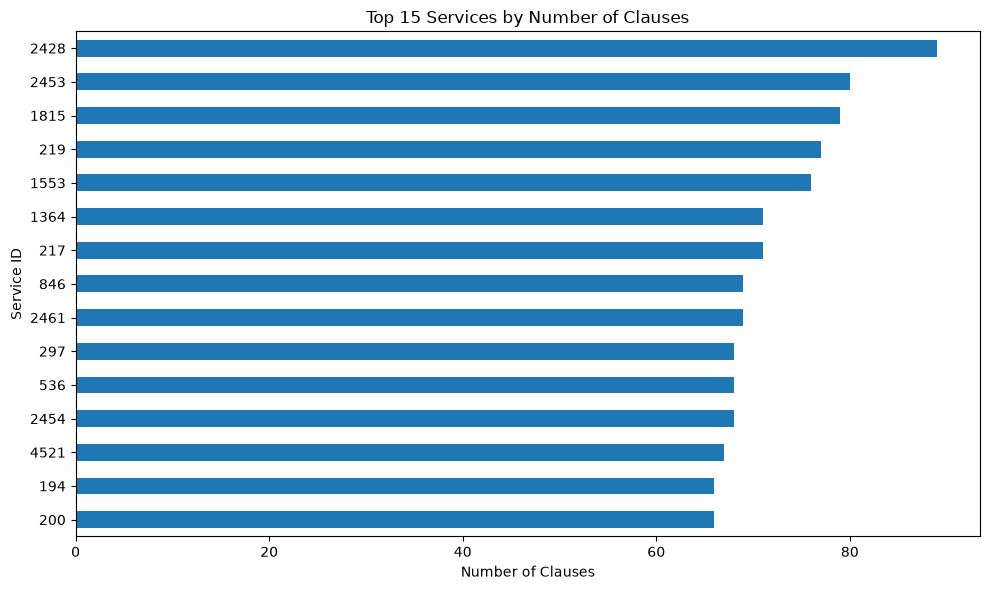

In [29]:
plt.figure(figsize=(10, 6))

service_counts.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Services by Number of Clauses")
plt.xlabel("Number of Clauses")
plt.ylabel("Service ID")

plt.tight_layout()
plt.show()

In [30]:
print("Number of documents:", dataset["document_id"].nunique())

Number of documents: 3109


In [31]:
document_counts = dataset["document_id"].value_counts()

print(document_counts.head(20))

document_id
7980.0    54
67.0      50
3287.0    48
1850.0    46
8696.0    45
2648.0    44
969.0     44
7991.0    44
3352.0    44
3172.0    42
346.0     40
3965.0    40
3173.0    40
408.0     40
1847.0    40
1880.0    40
2910.0    40
3291.0    39
2530.0    39
7733.0    39
Name: count, dtype: int64


In [32]:
print(
    "Duplicate quote_text:",
    dataset["quote_text"].duplicated().sum()
)

Duplicate quote_text: 344


In [33]:
from collections import Counter

all_words = []

for text in dataset["quote_text"]:
    all_words.extend(text.lower().split())

word_counts = Counter(all_words)

word_counts.most_common(30)

[('the', 29846),
 ('to', 25178),
 ('or', 24088),
 ('of', 21945),
 ('and', 20867),
 ('you', 15105),
 ('your', 12660),
 ('any', 11911),
 ('we', 9772),
 ('in', 9107),
 ('our', 7212),
 ('that', 7178),
 ('a', 7084),
 ('for', 7041),
 ('use', 6754),
 ('information', 6653),
 ('may', 6381),
 ('not', 5997),
 ('by', 5579),
 ('be', 5341),
 ('with', 5306),
 ('on', 4795),
 ('is', 4580),
 ('are', 4487),
 ('as', 4408),
 ('will', 4293),
 ('other', 4253),
 ('this', 4018),
 ('data', 3899),
 ('services', 3709)]

In [34]:
print("===== EDA SUMMARY =====")

print("Total clauses:", len(dataset))
print("Total topics:", dataset["topic_title"].nunique())
print("Total services:", dataset["service_id"].nunique())
print("Total documents:", dataset["document_id"].nunique())

print("\nClass distribution:")
print(dataset["label"].value_counts())

print("\nAverage clause length:")
print(dataset.groupby("label")["text_length"].mean().round(2))

print("\nAverage word count:")
print(dataset.groupby("label")["word_count"].mean().round(2))

print("\nDuplicate clauses:",
      dataset["quote_text"].duplicated().sum())

===== EDA SUMMARY =====
Total clauses: 22497
Total topics: 27
Total services: 1781
Total documents: 3109

Class distribution:
label
Neutral    9759
Risky      7015
Safe       5723
Name: count, dtype: int64

Average clause length:
label
Neutral    202.83
Risky      243.79
Safe       212.75
Name: text_length, dtype: float64

Average word count:
label
Neutral    31.92
Risky      37.75
Safe       33.15
Name: word_count, dtype: float64

Duplicate clauses: 344
